# Nettoyage des données - Aquifer Petrignano

## Objectif de ce notebook

Préparer un dataset **propre et complet** prêt pour la modélisation.

### Ce qu'on va faire :

1. Couper la période 2006-2009 (données météo manquantes) :
- 11 ans de données journalières, ça fait environ 4000 lignes. C'est largement suffisant pour le LSTM, beaucoup d'articles publiés travaillent avec moins. on ne perd pas en qualité scientifique. Au contraire, travailler avec des données 100% complètes est plus rigoureux que de mélanger deux sources avec des biais potentiels.

2. Traiter les valeurs manquantes restantes
3. Détecter et gérer les valeurs aberrantes (outliers)
4. Sauvegarder le dataset nettoyé

## Étape 1 : Charger les données et couper la période

On charge le dataset brut, on convertit les dates, et on ne garde que les données **à partir du 1er janvier 2009**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger le dataset brut
df = pd.read_csv('../data/raw/Nappe_Petrignano.csv')
# # df.head()
# Convertir la date
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date')
# df.head()
# df.loc[df['Rainfall_Bastia_Umbra'].isnull() == False]
print(f"Dataset brut : {df.shape[0]} lignes")
print(f"Période brute : {df['Date'].min().date()} → {df['Date'].max().date()}")

# Couper : garder uniquement à partir de 2009
df = df[df['Date'] >= '2009-01-01'].copy()

print(f"\nAprès coupure 2006-2009 :")
print(f"  → {df.shape[0]} lignes restantes")
print(f"  → Période : {df['Date'].min().date()} → {df['Date'].max().date()}")


Dataset brut : 5223 lignes
Période brute : 2006-03-14 → 2020-06-30

Après coupure 2006-2009 :
  → 4199 lignes restantes
  → Période : 2009-01-01 → 2020-06-30


## Étape 2 : Vérifier les valeurs manquantes après coupure


In [2]:
# Vérifier les NaN restantes
missing = pd.DataFrame({
    'Manquantes': df.isnull().sum(),
    'Pourcentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing.sort_values('Pourcentage (%)', ascending=False)

print("=== Valeurs manquantes après coupure 2006-2009 ===\n")
print(missing.to_string())
print(f"\n→ Total de lignes : {len(df)}")

=== Valeurs manquantes après coupure 2006-2009 ===

                                      Manquantes  Pourcentage (%)
Depth_to_Groundwater_P24                      39             0.93
Depth_to_Groundwater_P25                      27             0.64
Volume_C10_Petrignano                          1             0.02
Rainfall_Bastia_Umbra                          0             0.00
Date                                           0             0.00
Temperature_Bastia_Umbra                       0             0.00
Temperature_Petrignano                         0             0.00
Hydrometry_Fiume_Chiascio_Petrignano           0             0.00

→ Total de lignes : 4199


## Étape 3 : Traitement des valeurs manquantes restantes

Il reste 67 NaN au total, dispersées sur 3 colonnes :
- P24 : 39 NaN (0.93%)
- P25 : 27 NaN (0.64%)
- Volume : 1 NaN (0.02%)

On utilise l'**interpolation linéaire** pour les remplir.

Si on a les valeurs : 10, NaN, NaN, 16, 'interpolation calcule : 10, **12**, **14**, 16


In [3]:
# Colonnes numériques à interpoler (tout sauf Date)
colonnes_numeriques = df.columns.drop('Date')
# Avant interpolation : rappel des NaN
print("=== Avant interpolation ===")
print(f"NaN totaux : {df[colonnes_numeriques].isnull().sum().sum()}\n")

# Interpolation linéaire
df[colonnes_numeriques] = df[colonnes_numeriques].interpolate(method='linear') # pour chaque NaN, Pandas regarde la valeur avant et la valeur après, trace une ligne droite entre les deux, et calcule la valeur intermédiaire.

# Après interpolation : vérification
print("=== Après interpolation ===")
print(f"NaN totaux : {df[colonnes_numeriques].isnull().sum().sum()}")
print("\nDétail par colonne :")
print(df[colonnes_numeriques].isnull().sum().to_string())


=== Avant interpolation ===
NaN totaux : 67

=== Après interpolation ===
NaN totaux : 0

Détail par colonne :
Rainfall_Bastia_Umbra                   0
Depth_to_Groundwater_P24                0
Depth_to_Groundwater_P25                0
Temperature_Bastia_Umbra                0
Temperature_Petrignano                  0
Volume_C10_Petrignano                   0
Hydrometry_Fiume_Chiascio_Petrignano    0


## Étape 4 : Détection des valeurs aberrantes (outliers)

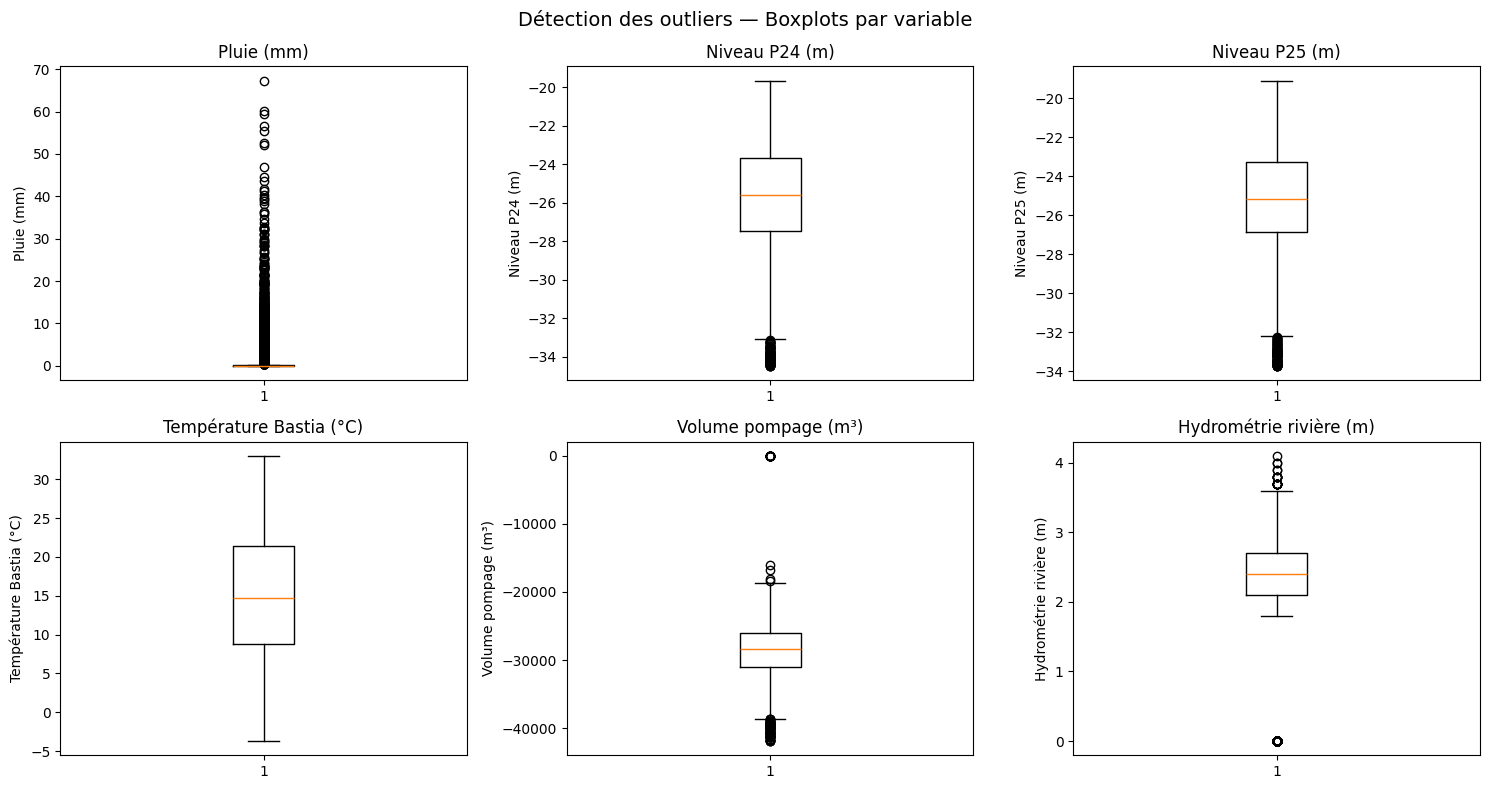

In [4]:
# Créer les boxplots pour chaque variable
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Détection des outliers — Boxplots par variable', fontsize=14)

variables = [
    ('Rainfall_Bastia_Umbra', 'Pluie (mm)', axes[0, 0]),
    ('Depth_to_Groundwater_P24', 'Niveau P24 (m)', axes[0, 1]),
    ('Depth_to_Groundwater_P25', 'Niveau P25 (m)', axes[0, 2]),
    ('Temperature_Bastia_Umbra', 'Température Bastia (°C)', axes[1, 0]),
    ('Volume_C10_Petrignano', 'Volume pompage (m³)', axes[1, 1]),
    ('Hydrometry_Fiume_Chiascio_Petrignano', 'Hydrométrie rivière (m)', axes[1, 2]),
]

for col, label, ax in variables:
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_ylabel(label)
    ax.set_title(label)

plt.tight_layout()
plt.savefig('../data/processed/8_fig_boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# print("→ Figure sauvegardée dans data/processed/")

## Étape 5 : Sauvegarde du dataset nettoyé

Notre dataset est maintenant :
- **Période** : 2009-01-01 → 2020-06-30 (11.5 ans)
- **Lignes** : 4199
- **NaN** : 0 (toutes traitées par interpolation)
- **Outliers** : aucun à supprimer (valeurs extrêmes mais réelles)

In [5]:
# Sauvegarder le dataset nettoyé
output_path = '../data/processed/Nappe_Petrignano_clean.csv'
df.to_csv(output_path, index=False)

# Vérification finale
df_check = pd.read_csv(output_path)
print("=== Dataset nettoyé sauvegardé ===\n")
print(f"Fichier : {output_path}")
print(f"Lignes  : {df_check.shape[0]}")
print(f"Colonnes: {df_check.shape[1]}")
print(f"NaN     : {df_check.isnull().sum().sum()}")
print(f"Période : {df_check['Date'].min()} → {df_check['Date'].max()}")
print(f"\nColonnes :")
for col in df_check.columns:
    print(f"  → {col}")

=== Dataset nettoyé sauvegardé ===

Fichier : ../data/processed/Nappe_Petrignano_clean.csv
Lignes  : 4199
Colonnes: 8
NaN     : 0
Période : 2009-01-01 → 2020-06-30

Colonnes :
  → Date
  → Rainfall_Bastia_Umbra
  → Depth_to_Groundwater_P24
  → Depth_to_Groundwater_P25
  → Temperature_Bastia_Umbra
  → Temperature_Petrignano
  → Volume_C10_Petrignano
  → Hydrometry_Fiume_Chiascio_Petrignano


In [ ]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 4))

# Tracer le niveau P24
ax.plot(df['Date'], df['Depth_to_Groundwater_P24'], 
        color='#2563EB', linewidth=0.8, label='Puits P24')

# Ajouter les bandes de saisons (on colorie chaque été en orange clair)
for year in range(2006, 2021):
    # Été : juin à septembre (saison sèche = nappe descend)
    summer_start = pd.Timestamp(f'{year}-06-01')
    summer_end = pd.Timestamp(f'{year}-09-30')
    ax.axvspan(summer_start, summer_end, alpha=0.12, color='#F59E0B')
    
    # Hiver : décembre à février (saison humide = nappe monte)
    winter_start = pd.Timestamp(f'{year}-12-01')
    winter_end = pd.Timestamp(f'{year+1}-02-28')
    ax.axvspan(winter_start, winter_end, alpha=0.12, color='#3B82F6')

# Seuil critique
ax.axhline(y=-30, color='red', linestyle='--', alpha=0.5, label='Seuil critique (-30m)')

# Légende des saisons
summer_patch = mpatches.Patch(color='#F59E0B', alpha=0.3, label='Été (juin-sept) → nappe descend')
winter_patch = mpatches.Patch(color='#3B82F6', alpha=0.3, label='Hiver (déc-fév) → nappe monte')
ax.legend(handles=[ax.get_lines()[0], ax.get_lines()[1], summer_patch, winter_patch], 
          loc='lower right', fontsize=9)

ax.set_ylabel('Niveau piézométrique (m)')
ax.set_xlabel('Date')
ax.set_title('Puits P24 — Niveau piézométrique avec saisons (2009-2020)')

plt.tight_layout()
plt.savefig('../data/processed/3_fig_niveaux_des_puits_au_fil_du_temps_avec_saisons.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée dans data/processed/")